In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 1 — Load and Merge the Dataset

In [ ]:
# ==========================================================
# STEP 2 (REVISED) — FULL FEATURE SET CLEANING & QUALITY ASSESSMENT
# Considers all 35 features (LT, NLT, LF, NLF domains), not entropy-only
# Excludes band-related features (alpha, beta, gamma, theta, delta)
# AND excludes any feature starting with "entropyProfiled"
# ==========================================================

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# LOAD MERGED DATASET
# ----------------------------------------------------------

data = pd.read_csv(
    "/content/drive/MyDrive/Merged_PreHI_HI_Entropy.csv"
)

print("="*70)
print("STEP 2 : FULL FEATURE SET CLEANING (excluding band-term features")
print("and entropyProfiled_* features)")
print("="*70)

# ----------------------------------------------------------
# METADATA COLUMNS
# ----------------------------------------------------------

metadata = [
    "patient_id",
    "segment_id",
    "Class"
]

# ----------------------------------------------------------
# TERMS TO EXCLUDE (substring match, case-insensitive)
# ----------------------------------------------------------

excluded_terms = ["alpha", "beta", "gamma", "theta", "delta"]

# ----------------------------------------------------------
# PREFIX TO EXCLUDE (startswith match, case-insensitive)
# ----------------------------------------------------------

excluded_prefixes = ["entropyprofiled"]

def is_excluded(col_name):
    name = col_name.lower()
    if any(term in name for term in excluded_terms):
        return True
    if any(name.startswith(prefix) for prefix in excluded_prefixes):
        return True
    return False

# ----------------------------------------------------------
# KEEP ALL EXTRACTED FEATURES, EXCLUDING BAND-TERM AND
# entropyProfiled_* COLUMNS
# ----------------------------------------------------------

all_features = [
    c for c in data.columns
    if c not in metadata
    and not is_excluded(c)
]

excluded_cols = [
    c for c in data.columns
    if c not in metadata
    and is_excluded(c)
]

print("\nTotal Candidate Features Found :", len(all_features))
print(all_features)

print("\nExcluded Features (band-term or entropyProfiled_*) :", len(excluded_cols))
print(excluded_cols)

full_df = data[metadata + all_features].copy()

# ----------------------------------------------------------
# REPLACE INF
# ----------------------------------------------------------

full_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# ----------------------------------------------------------
# REMOVE FEATURES WITH NaN
# ----------------------------------------------------------

feature_cols = [c for c in full_df.columns if c not in metadata]

nan_remove = []

for col in feature_cols:
    if full_df[col].isna().sum() > 0:
        nan_remove.append(col)

full_df.drop(columns=nan_remove, inplace=True)

print("\nRemoved NaN Features")
print(nan_remove)

# ----------------------------------------------------------
# REMOVE CONSTANT FEATURES
# ----------------------------------------------------------

feature_cols = [c for c in full_df.columns if c not in metadata]

constant_remove = []

for col in feature_cols:
    if full_df[col].nunique() <= 1:
        constant_remove.append(col)

full_df.drop(columns=constant_remove, inplace=True)

print("\nRemoved Constant Features")
print(constant_remove)

# ----------------------------------------------------------
# REMOVE NEAR CONSTANT FEATURES
# Variance < 1e-10
# ----------------------------------------------------------

feature_cols = [c for c in full_df.columns if c not in metadata]

near_constant = []

for col in feature_cols:
    if full_df[col].var() < 1e-10:
        near_constant.append(col)

full_df.drop(columns=near_constant, inplace=True)

print("\nRemoved Near Constant Features")
print(near_constant)

# ----------------------------------------------------------
# FINAL FEATURE LIST
# ----------------------------------------------------------

feature_cols = [c for c in full_df.columns if c not in metadata]

print("\nFinal Feature Set (post-QA)")
for i, f in enumerate(feature_cols, 1):
    print(f"{i:2d}. {f}")

print("\nNumber of Final Features :", len(feature_cols))

# ----------------------------------------------------------
# BASIC QA REPORT
# ----------------------------------------------------------

print("\nDataset Shape :", full_df.shape)
print("Patients :", full_df["patient_id"].nunique())
print("Pre-HI Segments :", (full_df["Class"]==0).sum())
print("HI Segments :", (full_df["Class"]==1).sum())

print("\nMissing Values")
print(full_df.isna().sum().sum())

print("Infinite Values")
print(np.isinf(full_df.select_dtypes(include=np.number)).sum().sum())

# ----------------------------------------------------------
# SAVE CLEAN DATASET
# ----------------------------------------------------------

save_path = "/content/drive/MyDrive/FullFeatureDataset_Clean.csv"

full_df.to_csv(save_path, index=False)

print("\nSaved Clean Dataset")
print(save_path)

STEP 2 : FULL FEATURE SET CLEANING (excluding band-term features
and entropyProfiled_* features)

Total Candidate Features Found : 38
['maximum', 'minimum', 'mean', 'median', 'standardDeviation', 'variance', 'kurtosis', 'skewness', 'numberOfZeroCrossing', 'positiveToNegativeSampleRatio', 'positiveToNegativePeakRatio', 'meanAbsoluteValue', 'approximateEntropy', 'sampleEntropy', 'permutationEntropy', 'singularValueDecompositionEntropy', 'fuzzyEntropy', 'distributionEntropy', 'shannonEntropy', 'renyiEntropy', 'lempelZivComplexity', 'hjorthMobility', 'hjorthComplexity', 'fisherInfo', 'petrosianFd', 'katzFd', 'higuchiFd', 'detrendedFluctuation', 'fd_maximum', 'fd_minimum', 'fd_mean', 'fd_median', 'fd_standardDeviation', 'fd_variance', 'fd_kurtosis', 'fd_skewness', 'spectralEntropy', 'fd_bandPower']

Excluded Features (band-term or entropyProfiled_*) : 54
['entropyProfiled_total_sampleEntropy', 'entropyProfiled_average_sampleEntropy', 'entropyProfiled_maximum_sampleEntropy', 'entropyProfiled

LEAKAGE-FREE NESTED LOSO CLASSIFICATION WITH EMBEDDED RF-IMPORTANCE
FEATURE SELECTION — ECG / Hemodynamic Instability (HI)

In [ ]:
"""
=========================================================================
LEAKAGE-FREE NESTED LOSO CLASSIFICATION WITH EMBEDDED RF-IMPORTANCE
FEATURE SELECTION — ECG / Hemodynamic Instability (HI)
=========================================================================

This is the ML-only reframing of the original two-arm study. It removes
the statistical arm entirely (no LMM, no FDR, no Cohen's d, no LASSO
run) and keeps a single pipeline:

    raw features -> nested LOSO -> RF-importance embedded selection
                  -> Spearman redundancy pruning -> patient-baseline
                  normalization -> classifier(s) -> pooled AUC + CI

Outputs (written to OUTPUT_DIR):
    - oof_predictions.csv         per-segment out-of-fold predicted scores
    - per_patient_auc.csv         AUC broken out by held-out patient
    - feature_stability.csv       fold-selection frequency + mean importance
    - final_feature_importance.csv  descriptive full-data RF importances
    - roc_curve.png               pooled ROC curve, all classifiers
    - summary.txt                 headline numbers for the manuscript

Edit the CONFIG block below to point at your data and choose classifiers.
"""

import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix

# =========================================================================
# CONFIG
# =========================================================================

DATA_PATH = "/content/drive/MyDrive/FullFeatureDataset_Clean.csv"  # <-- edit
OUTPUT_DIR = Path("/content/drive/MyDrive/RF_LOSO_Outputs")        # <-- edit

PATIENT_COL = "patient_id"
SEGMENT_COL = "segment_id"
LABEL_COL = "Class"          # 0 = pre-HI, 1 = HI
METADATA_COLS = [PATIENT_COL, SEGMENT_COL, LABEL_COL]

TOP_K = 12                   # features kept by RF-importance per fold
CORR_THRESH = 0.90           # Spearman redundancy threshold
N_BOOT = 1000                # bootstrap resamples for AUC CI
RANDOM_STATE = 42

# Which classifiers to run downstream of RF-importance selection.
# Keep all four to preserve the linear-vs-nonlinear comparison from the
# paper; drop to just {"RF": ...} if you only want one classifier.
CLASSIFIERS_FACTORY = lambda: {
    "LR": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "RF": RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
    "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

# =========================================================================
# STEP 1 — LOAD
# =========================================================================

def load_data(path):
    df = pd.read_csv(path)
    df[PATIENT_COL] = df[PATIENT_COL].astype(str)
    feature_cols = [c for c in df.columns if c not in METADATA_COLS]
    return df, feature_cols


# =========================================================================
# STEP 2 — EMBEDDED RF-IMPORTANCE FEATURE SELECTION (fold-internal)
# =========================================================================

def select_features_rf(X_train, y_train, feature_names, top_k=TOP_K,
                        corr_thresh=CORR_THRESH, random_state=RANDOM_STATE):
    """Fit an RF on the training fold only, rank by Gini importance,
    keep the top_k, then drop redundant partners (|Spearman rho|>thresh),
    always keeping the higher-importance member of a correlated pair.
    Returns (selected_features, full_importance_series)."""

    rf = RandomForestClassifier(n_estimators=500, random_state=random_state, n_jobs=-1)
    rf.fit(X_train[feature_names], y_train)

    importance = pd.Series(rf.feature_importances_, index=feature_names)
    top_feats = importance.sort_values(ascending=False).head(top_k).index.tolist()

    corr = X_train[top_feats].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    remove = set()
    for c in upper.columns:
        high = upper.index[upper[c] > corr_thresh]
        for r in high:
            if importance[r] < importance[c]:
                remove.add(r)
            else:
                remove.add(c)

    selected = [f for f in top_feats if f not in remove]
    return selected, importance


# =========================================================================
# STEP 3 — PATIENT-BASELINE NORMALIZATION
# =========================================================================

def baseline_normalize(X_train, y_train, g_train, X_test, y_test,
                        feats, patient_col=PATIENT_COL):
    """Express each segment relative to that patient's own pre-HI (Class=0)
    mean. Train patients use train-fold-only baselines. The held-out
    patient uses its OWN pre-HI segments (a legitimate calibration step,
    mirroring an initial monitoring period at deployment, not leakage)."""

    train_baseline = X_train.loc[y_train == 0, feats].copy()
    train_baseline[patient_col] = g_train[y_train == 0]
    train_pat_baseline = train_baseline.groupby(patient_col)[feats].mean()

    Xtr_norm = X_train[feats].copy()
    for pid in np.unique(g_train):
        mask = g_train == pid
        if pid in train_pat_baseline.index:
            Xtr_norm.loc[mask] = X_train.loc[mask, feats].values - train_pat_baseline.loc[pid].values

    test_baseline = X_test[feats].loc[y_test == 0].mean() if (y_test == 0).any() else X_test[feats].mean()
    Xte_norm = X_test[feats] - test_baseline

    return Xtr_norm, Xte_norm


# =========================================================================
# STEP 4 — NESTED LOSO LOOP
# =========================================================================

def run_nested_loso(df, feature_cols):
    X_all = df[feature_cols].copy()
    y_all = df[LABEL_COL].values
    groups = df[PATIENT_COL].values

    logo = LeaveOneGroupOut()
    oof_scores = {name: np.zeros(len(y_all)) for name in CLASSIFIERS_FACTORY()}
    fold_feature_log = []
    fold_importance_log = []   # list of pd.Series, one per fold, full-length
    fold_results = []

    for train_idx, test_idx in logo.split(X_all, y_all, groups):
        X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
        y_train, y_test = y_all[train_idx], y_all[test_idx]
        g_train, g_test = groups[train_idx], groups[test_idx]
        test_patient = g_test[0]

        feats, importance = select_features_rf(X_train, y_train, feature_cols)
        fold_feature_log.append(feats)
        fold_importance_log.append(importance)

        Xtr_norm, Xte_norm = baseline_normalize(
            X_train, y_train, g_train, X_test, y_test, feats
        )

        scaler = StandardScaler().fit(Xtr_norm)
        Xtr = scaler.transform(Xtr_norm)
        Xte = scaler.transform(Xte_norm)

        classifiers = CLASSIFIERS_FACTORY()
        for name, clf in classifiers.items():
            clf.fit(Xtr, y_train)
            if hasattr(clf, "predict_proba"):
                pos_idx = list(clf.classes_).index(1)
                scores = clf.predict_proba(Xte)[:, pos_idx]
            else:
                scores = clf.decision_function(Xte)
            oof_scores[name][test_idx] = scores

            fold_auc = roc_auc_score(y_test, scores) if len(set(y_test)) > 1 else np.nan
            fold_results.append({
                "patient": test_patient, "classifier": name,
                "n_features": len(feats), "auc": fold_auc,
            })

    return {
        "y_all": y_all,
        "groups": groups,
        "oof_scores": oof_scores,
        "fold_results": pd.DataFrame(fold_results),
        "fold_feature_log": fold_feature_log,
        "fold_importance_log": fold_importance_log,
    }


# =========================================================================
# STEP 5 — BOOTSTRAP AUC CI (patient-level resampling)
# =========================================================================

def bootstrap_auc_ci(y_all, scores, groups, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    patients = np.unique(groups)
    boot_aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([np.where(groups == p)[0] for p in sampled])
        if len(np.unique(y_all[idx])) > 1:
            try:
                boot_aucs.append(roc_auc_score(y_all[idx], scores[idx]))
            except ValueError:
                continue
    point = roc_auc_score(y_all, scores)
    ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
    return point, ci_low, ci_high


# =========================================================================
# STEP 6 — FEATURE STABILITY (selection frequency + mean importance)
# =========================================================================

def summarize_feature_stability(fold_feature_log, fold_importance_log, n_folds):
    flat = [f for fold in fold_feature_log for f in fold]
    freq = Counter(flat)

    importance_df = pd.concat(fold_importance_log, axis=1)  # features x folds
    mean_importance = importance_df.mean(axis=1)
    std_importance = importance_df.std(axis=1)

    table = pd.DataFrame({
        "feature": mean_importance.index,
        "folds_selected": [freq.get(f, 0) for f in mean_importance.index],
        "folds_selected_pct": [freq.get(f, 0) / n_folds * 100 for f in mean_importance.index],
        "mean_gini_importance": mean_importance.values,
        "std_gini_importance": std_importance.values,
    }).sort_values(["folds_selected", "mean_gini_importance"], ascending=False)

    return table.reset_index(drop=True)


# =========================================================================
# STEP 7 — DESCRIPTIVE FULL-DATA RF FIT (final importance ranking)
# =========================================================================
# NOTE: this is NOT used for any performance estimate — it is a single
# RF trained on the whole (baseline-normalized) dataset purely to report
# one clean, final "top predictive features" table. Label it as
# descriptive in the manuscript, separate from the leakage-free LOSO AUC.

def final_descriptive_importance(df, feature_cols, top_k=TOP_K):
    baseline = df.loc[df[LABEL_COL] == 0].groupby(PATIENT_COL)[feature_cols].mean()

    X_norm = df[feature_cols].copy()
    for pid in df[PATIENT_COL].unique():
        mask = df[PATIENT_COL] == pid
        if pid in baseline.index:
            X_norm.loc[mask] = df.loc[mask, feature_cols].values - baseline.loc[pid].values

    y_all = df[LABEL_COL].values
    rf_final = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
    rf_final.fit(X_norm, y_all)

    importance = pd.Series(rf_final.feature_importances_, index=feature_cols)
    top = importance.sort_values(ascending=False).head(top_k)
    return top.reset_index().rename(columns={"index": "feature", 0: "gini_importance"})


# =========================================================================
# STEP 8 — ROC PLOT
# =========================================================================

def plot_roc(y_all, oof_scores, out_path):
    plt.figure(figsize=(6, 6), dpi=300)
    for name, scores in oof_scores.items():
        fpr, tpr, _ = roc_curve(y_all, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Pooled LOSO ROC — RF-importance feature selection")
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


# =========================================================================
# MAIN
# =========================================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    df, feature_cols = load_data(DATA_PATH)
    n_folds = df[PATIENT_COL].nunique()
    print(f"Patients: {n_folds} | Segments: {len(df)} | Candidate features: {len(feature_cols)}")

    results = run_nested_loso(df, feature_cols)
    y_all, groups, oof_scores = results["y_all"], results["groups"], results["oof_scores"]

    # ---- headline AUCs + bootstrap CI ----
    summary_lines = ["Pooled LOSO AUC (RF-importance embedded feature selection):\n"]
    for name, scores in oof_scores.items():
        point, lo, hi = bootstrap_auc_ci(y_all, scores, groups)
        line = f"  {name}: AUC = {point:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]"
        print(line)
        summary_lines.append(line)

    # ---- per-patient AUC table ----
    per_patient = results["fold_results"].pivot(index="patient", columns="classifier", values="auc")
    per_patient.to_csv(OUTPUT_DIR / "per_patient_auc.csv")

    # ---- out-of-fold predictions ----
    oof_df = df[[PATIENT_COL, SEGMENT_COL, LABEL_COL]].copy()
    for name, scores in oof_scores.items():
        oof_df[f"score_{name}"] = scores
    oof_df.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)

    # ---- feature stability (frequency + magnitude) ----
    stability_table = summarize_feature_stability(
        results["fold_feature_log"], results["fold_importance_log"], n_folds
    )
    stability_table.to_csv(OUTPUT_DIR / "feature_stability.csv", index=False)
    print("\nTop 15 features by fold-selection frequency / mean importance:")
    print(stability_table.head(15).to_string(index=False))

    # ---- final descriptive full-data importance ranking ----
    final_importance = final_descriptive_importance(df, feature_cols)
    final_importance.to_csv(OUTPUT_DIR / "final_feature_importance.csv", index=False)
    print("\nFinal descriptive RF feature importance (full dataset, for reporting only):")
    print(final_importance.to_string(index=False))

    # ---- ROC plot ----
    plot_roc(y_all, oof_scores, OUTPUT_DIR / "roc_curve.png")

    with open(OUTPUT_DIR / "summary.txt", "w") as f:
        f.write("\n".join(summary_lines))

    print(f"\nAll outputs written to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Patients: 20 | Segments: 1260 | Candidate features: 35
  LR: AUC = 0.472, 95% CI = [0.342, 0.613]
  LDA: AUC = 0.473, 95% CI = [0.343, 0.615]
  RF: AUC = 0.796, 95% CI = [0.709, 0.888]
  SVM: AUC = 0.716, 95% CI = [0.608, 0.827]

Top 15 features by fold-selection frequency / mean importance:
                          feature  folds_selected  folds_selected_pct  mean_gini_importance  std_gini_importance
                    sampleEntropy              20               100.0              0.056929             0.004272
                         skewness              20               100.0              0.055027             0.003909
                  spectralEntropy              20               100.0              0.040064             0.002342
    positiveToNegativeSampleRatio              19                95.0              0.048175             0.005159
               permutationEntropy              19                95.0              0.039872             0.003174
singularValueDecompositionEnt

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

TOP_K = 12
CORR_THRESH = 0.90
RANDOM_STATE = 42


def select_features_rf(X_train, y_train, feature_names,
                        top_k=TOP_K, corr_thresh=CORR_THRESH,
                        random_state=RANDOM_STATE):
    """Fit RF on the training fold only, rank by Gini importance,
    keep top_k, then drop redundant partners (|Spearman rho| > thresh),
    keeping the higher-importance member of each correlated pair.
    Returns (selected_features, full_importance_series)."""
    rf = RandomForestClassifier(n_estimators=500, random_state=random_state, n_jobs=-1)
    rf.fit(X_train[feature_names], y_train)

    importance = pd.Series(rf.feature_importances_, index=feature_names)
    top_feats = importance.sort_values(ascending=False).head(top_k).index.tolist()

    corr = X_train[top_feats].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    remove = set()
    for c in upper.columns:
        high = upper.index[upper[c] > corr_thresh]
        for r in high:
            if importance[r] < importance[c]:
                remove.add(r)
            else:
                remove.add(c)

    selected = [f for f in top_feats if f not in remove]
    return selected, importance


def summarize_feature_stability(fold_feature_log, fold_importance_log, n_folds):
    """fold_feature_log: list of length n_folds, each a list of the
    features selected in that fold.
    fold_importance_log: list of length n_folds, each a full-length
    pd.Series of Gini importances (index = all candidate features)."""
    flat = [f for fold in fold_feature_log for f in fold]
    freq = Counter(flat)

    importance_df = pd.concat(fold_importance_log, axis=1)  # features x folds
    mean_importance = importance_df.mean(axis=1)
    std_importance = importance_df.std(axis=1)

    table = pd.DataFrame({
        "feature": mean_importance.index,
        "folds_selected": [freq.get(f, 0) for f in mean_importance.index],
        "folds_selected_pct": [freq.get(f, 0) / n_folds * 100 for f in mean_importance.index],
        "mean_gini_importance": mean_importance.values,
        "std_gini_importance": std_importance.values,
    }).sort_values(["folds_selected", "mean_gini_importance"], ascending=False)

    return table.reset_index(drop=True)

STEP 8 – FEATURE STABILITY VISUALIZATION

    Rank                            feature  folds_selected  \
0      1                      sampleEntropy              20   
1      2                           skewness              20   
2      3                    spectralEntropy              20   
3      4      positiveToNegativeSampleRatio              19   
4      5                 permutationEntropy              19   
5      6  singularValueDecompositionEntropy              18   
6      7                           kurtosis              18   
7      8                          fd_median              17   
8      9                          higuchiFd              16   
9     10               numberOfZeroCrossing              16   
10    11                        fd_variance               9   
11    12               fd_standardDeviation               7   
12    13               detrendedFluctuation               7   
13    14                  meanAbsoluteValue               1   
14    15                            maximum            

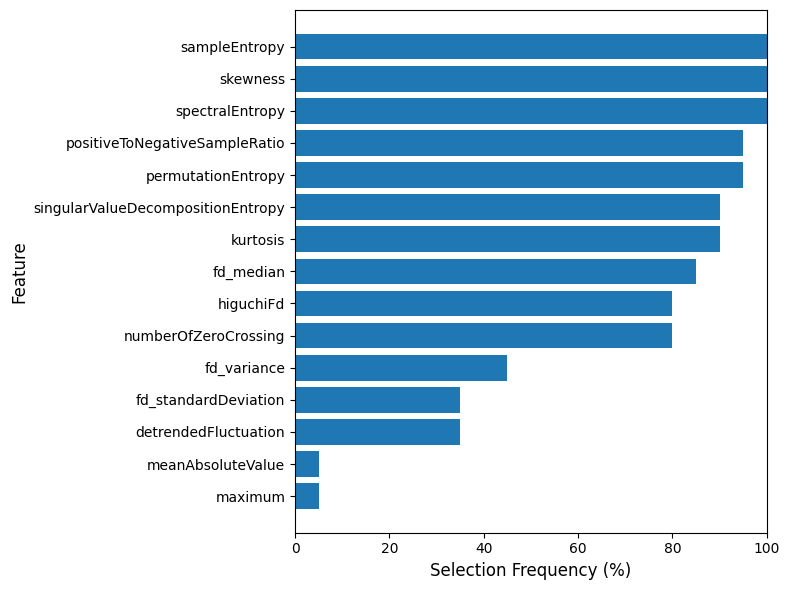

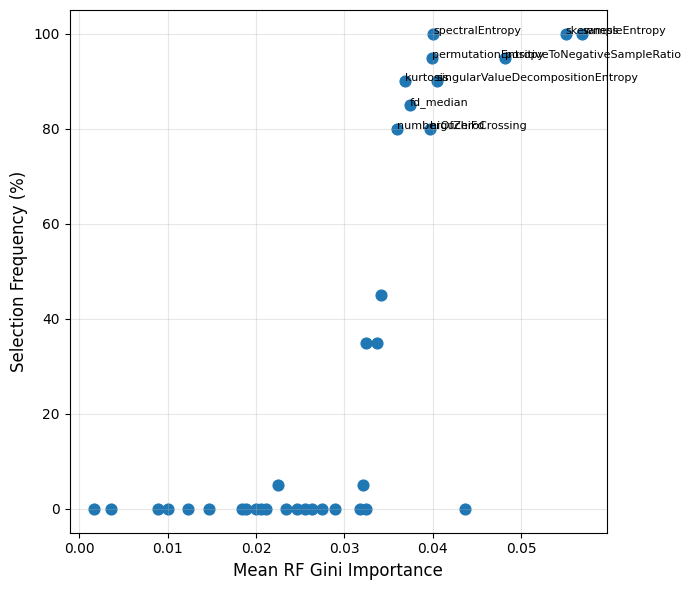

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Load feature stability table
# --------------------------------------------------

stability = pd.read_csv(
    "/content/drive/MyDrive/RF_LOSO_Outputs/feature_stability.csv"
)

# --------------------------------------------------
# Sort
# --------------------------------------------------

stability = stability.sort_values(
    ["folds_selected", "mean_gini_importance"],
    ascending=False
).reset_index(drop=True)

###############################################################
# TABLE 1
###############################################################

table = stability.copy()
table.insert(0, "Rank", range(1, len(table)+1))

table.to_csv(
    "/content/drive/MyDrive/RF_LOSO_Outputs/Table_StablePredictiveFeatures.csv",
    index=False
)

print(table.head(20))

###############################################################
# FIGURE 1
# Selection Frequency
###############################################################

top = stability.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top["feature"],
    top["folds_selected_pct"]
)

plt.xlabel("Selection Frequency (%)", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.xlim(0,100)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/RF_LOSO_Outputs/Figure1_FeatureSelectionFrequency.png",
    dpi=600
)

plt.show()

###############################################################
# FIGURE 2
# Stability vs Importance
###############################################################

plt.figure(figsize=(7,6))

plt.scatter(
    stability["mean_gini_importance"],
    stability["folds_selected_pct"],
    s=60
)

top10 = stability.head(10)

for _, row in top10.iterrows():

    plt.text(
        row["mean_gini_importance"],
        row["folds_selected_pct"],
        row["feature"],
        fontsize=8
    )

plt.xlabel("Mean RF Gini Importance", fontsize=12)
plt.ylabel("Selection Frequency (%)", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/RF_LOSO_Outputs/Figure2_StabilityVsImportance.png",
    dpi=600
)

plt.show()

Figure 3A – Lollipop Chart (Top 20 Stable Features)

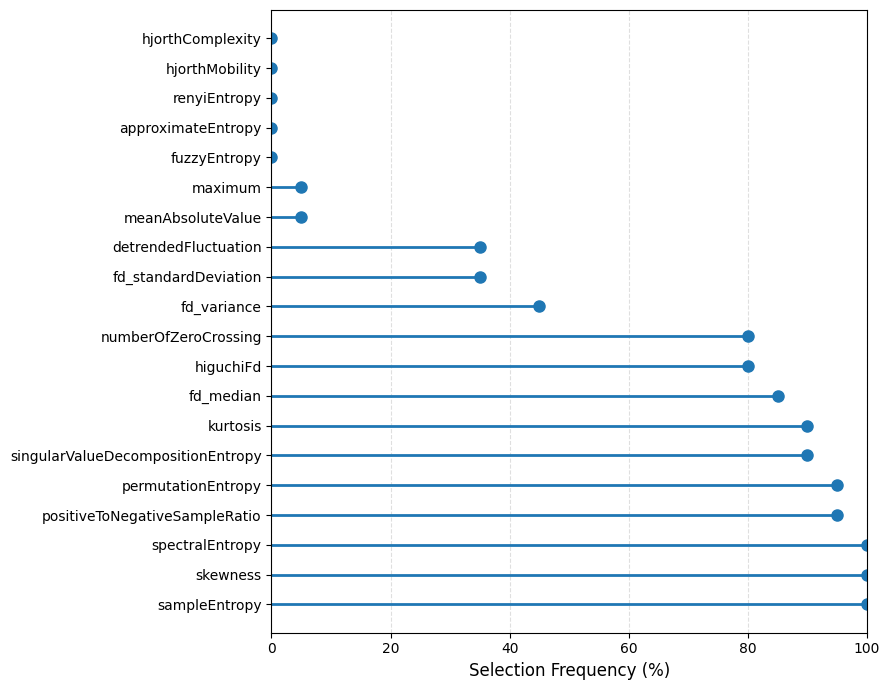

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/content/drive/MyDrive/RF_LOSO_Outputs/feature_stability.csv")

# Top 20 stable features
df = df.sort_values(
    ["folds_selected", "mean_gini_importance"],
    ascending=False
).head(20)

plt.figure(figsize=(9,7))

plt.hlines(
    y=df["feature"],
    xmin=0,
    xmax=df["folds_selected_pct"],
    linewidth=2
)

plt.plot(
    df["folds_selected_pct"],
    df["feature"],
    "o",
    markersize=8
)

plt.xlabel("Selection Frequency (%)", fontsize=12)
plt.ylabel("")
plt.xlim(0,100)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/RF_LOSO_Outputs/Figure3A_Lollipop.png",
    dpi=600
)

plt.show()

Figure 3B – Bubble Plot

Bubble size represents mean Gini importance.

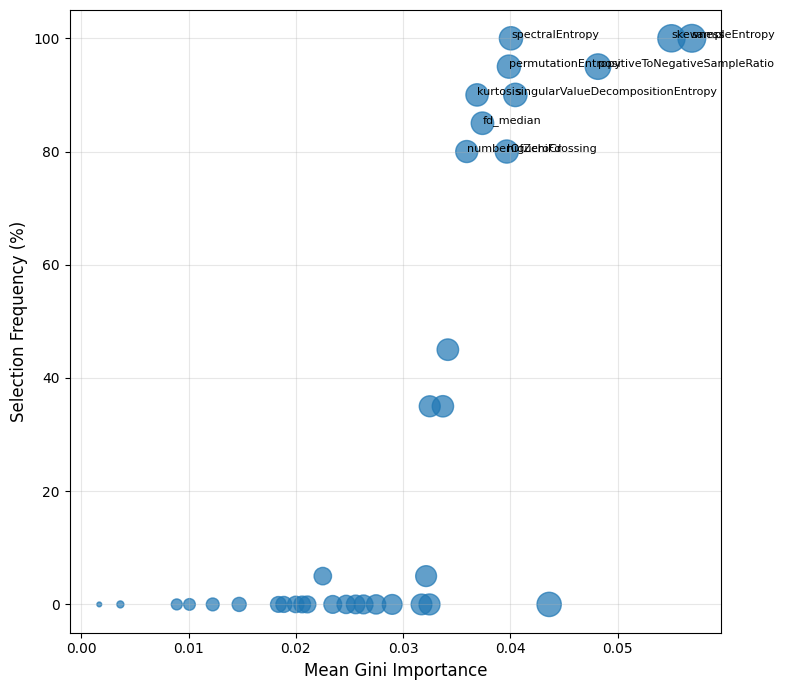

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/RF_LOSO_Outputs/feature_stability.csv")

plt.figure(figsize=(8,7))

bubble_size = df["mean_gini_importance"] * 7000

plt.scatter(
    df["mean_gini_importance"],
    df["folds_selected_pct"],
    s=bubble_size,
    alpha=0.7
)

top10 = df.sort_values(
    ["folds_selected","mean_gini_importance"],
    ascending=False
).head(10)

for _, row in top10.iterrows():

    plt.text(
        row["mean_gini_importance"],
        row["folds_selected_pct"],
        row["feature"],
        fontsize=8
    )

plt.xlabel("Mean Gini Importance", fontsize=12)
plt.ylabel("Selection Frequency (%)", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/RF_LOSO_Outputs/Figure3B_Bubble.png",
    dpi=600
)

plt.show()

Figure 3C – Pareto Chart

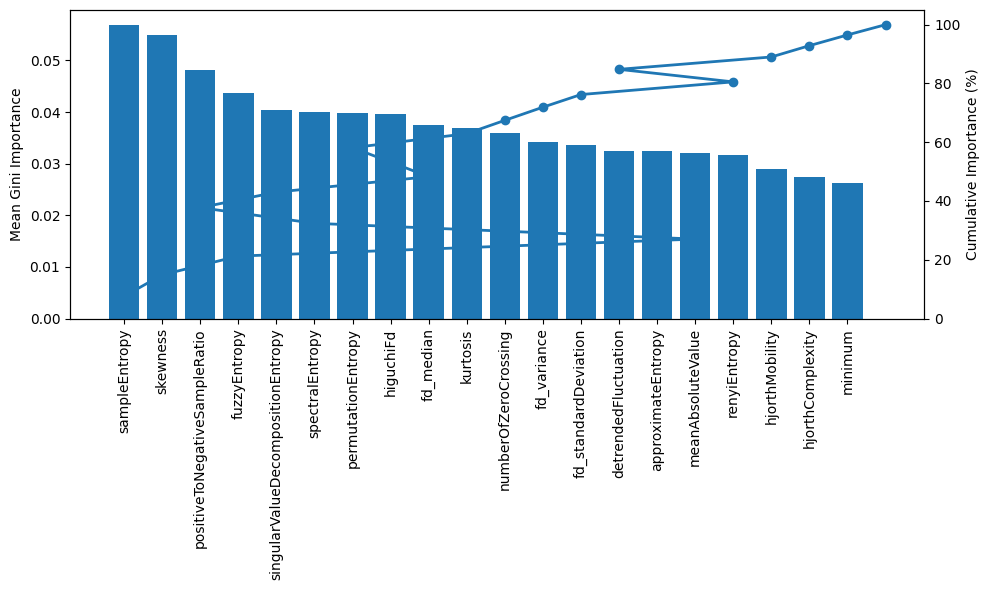

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/RF_LOSO_Outputs/feature_stability.csv")

df = df.sort_values(
    "mean_gini_importance",
    ascending=False
).head(20)

df["cumulative"] = (
    df["mean_gini_importance"].cumsum()
    / df["mean_gini_importance"].sum()
) * 100

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(
    df["feature"],
    df["mean_gini_importance"]
)

ax1.set_ylabel("Mean Gini Importance")
ax1.set_xticklabels(df["feature"], rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    df["cumulative"],
    marker="o",
    linewidth=2
)

ax2.set_ylim(0,105)
ax2.set_ylabel("Cumulative Importance (%)")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/RF_LOSO_Outputs/Figure3C_Pareto.png",
    dpi=600
)

plt.show()

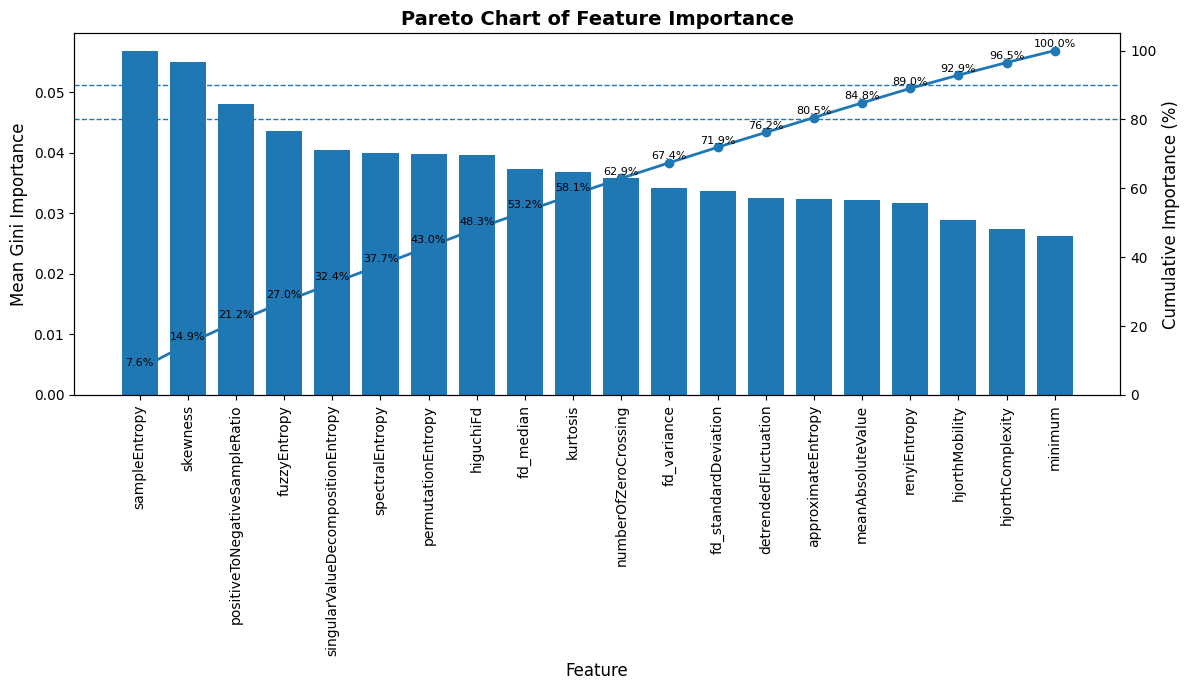

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Load feature stability table
# --------------------------------------------------

df = pd.read_csv(
    "/content/drive/MyDrive/RF_LOSO_Outputs/feature_stability.csv"
)

# --------------------------------------------------
# Select top 20 features by mean importance
# --------------------------------------------------

df = df.sort_values(
    by="mean_gini_importance",
    ascending=False
).head(20).reset_index(drop=True)

# --------------------------------------------------
# Calculate cumulative importance (%)
# --------------------------------------------------

df["cumulative_importance"] = (
    df["mean_gini_importance"].cumsum()
    / df["mean_gini_importance"].sum()
) * 100

# --------------------------------------------------
# Plot Pareto Chart
# --------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 7))

x = np.arange(len(df))

# Bar plot
ax1.bar(
    x,
    df["mean_gini_importance"],
    width=0.75
)

ax1.set_ylabel("Mean Gini Importance", fontsize=12)
ax1.set_xlabel("Feature", fontsize=12)

ax1.set_xticks(x)
ax1.set_xticklabels(
    df["feature"],
    rotation=90,
    ha="center"
)

# Second axis for cumulative percentage
ax2 = ax1.twinx()

ax2.plot(
    x,
    df["cumulative_importance"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Cumulative Importance (%)", fontsize=12)
ax2.set_ylim(0, 105)

# Add horizontal reference lines
ax2.axhline(80, linestyle="--", linewidth=1)
ax2.axhline(90, linestyle="--", linewidth=1)

# Annotate cumulative percentages
for i, value in enumerate(df["cumulative_importance"]):
    ax2.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=8
    )

plt.title(
    "Pareto Chart of Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/RF_LOSO_Outputs/Figure3_ParetoChart.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Ablation study

In [ ]:
import pandas as pd

# ----------------------------------------------------------
# Load cleaned dataset
# ----------------------------------------------------------

df = pd.read_csv("/content/drive/MyDrive/FullFeatureDataset_Clean.csv")

# ----------------------------------------------------------
# Define columns
# ----------------------------------------------------------

TARGET = "Class" # Corrected from "Label"
PATIENT = "patient_id" # Corrected from "PatientID"

feature_cols = [
    c for c in df.columns
    if c not in [TARGET, PATIENT]
]

# ----------------------------------------------------------
# Features to test
# ----------------------------------------------------------

ablation_features = [
    None,                           # Full model
    "sampleEntropy",
    "skewness",
    "positiveToNegativeSampleRatio",
    "fuzzyEntropy"
]

summary = []

for feature in ablation_features:

    if feature is None:

        current_features = feature_cols
        model_name = "Full Model"

    else:

        current_features = [
            f for f in feature_cols
            if f != feature
        ]

        model_name = f"Without {feature}"

    print("="*60)
    print(model_name)
    print("="*60)

    # The run_nested_loso function expects PATIENT_COL and LABEL_COL from the global scope (defined in whvNu4NTOlG8)
    # It also relies on the patient_id and Class columns to be present in df
    # Passing a subset of feature_cols might be fine, but the function needs the original df for groups and labels

    # To pass a modified df and corresponding feature_cols to run_nested_loso for ablation:
    # Ensure the df used by run_nested_loso has only the `current_features` plus metadata

    # Re-aligning the df with current_features and metadata for the run_nested_loso function
    # The PATIENT_COL and LABEL_COL are assumed to be 'patient_id' and 'Class' by run_nested_loso
    # These are defined in cell whvNu4NTOlG8 in its global scope.
    # So, we need to pass a df that has 'patient_id' and 'Class' along with the current_features.

    # Create a temporary df for the run_nested_loso call, including metadata columns
    df_ablated = df[[PATIENT, TARGET] + current_features].copy()

    results = run_nested_loso(df_ablated, current_features)

    # Calculate pooled AUC for the 'RF' classifier from the oof_scores
    # bootstrap_auc_ci returns (point, ci_low, ci_high)
    pooled_auc_rf, _, _ = bootstrap_auc_ci(
        results["y_all"],
        results["oof_scores"]["RF"],
        results["groups"]
    )

    summary.append({
        "Model": model_name,
        "AUC": pooled_auc_rf # Corrected to get AUC from RF scores
    })

summary = pd.DataFrame(summary)

summary["ΔAUC"] = (
    summary["AUC"]
    - summary.loc[0, "AUC"]
)

print(summary)

summary.to_csv(
    "/content/drive/MyDrive/RF_LOSO_Outputs/AblationStudy.csv",
    index=False
)


Full Model
Without sampleEntropy
Without skewness
Without positiveToNegativeSampleRatio
Without fuzzyEntropy
                                   Model       AUC      ΔAUC
0                             Full Model  0.808355  0.000000
1                  Without sampleEntropy  0.807857 -0.000498
2                       Without skewness  0.801064 -0.007291
3  Without positiveToNegativeSampleRatio  0.772387 -0.035968
4                   Without fuzzyEntropy  0.787306 -0.021049


In [ ]:
"""
=========================================================================
LEAKAGE-FREE NESTED LOSO CLASSIFICATION WITH EMBEDDED RF-IMPORTANCE
FEATURE SELECTION — ECG / Hemodynamic Instability (HI)
=========================================================================

This is the ML-only reframing of the original two-arm study. It removes
the statistical arm entirely (no LMM, no FDR, no Cohen's d, no LASSO
run) and keeps a single pipeline:

    raw features -> nested LOSO -> RF-importance embedded selection
                  -> Spearman redundancy pruning -> patient-baseline
                  normalization -> classifier(s) -> pooled AUC + CI

Outputs (written to OUTPUT_DIR):
    - oof_predictions.csv         per-segment out-of-fold predicted scores
    - per_patient_auc.csv         AUC broken out by held-out patient
    - feature_stability.csv       fold-selection frequency + mean importance
    - final_feature_importance.csv  descriptive full-data RF importances
    - roc_curve.png               pooled ROC curve, all classifiers
    - summary.txt                 headline numbers for the manuscript

Edit the CONFIG block below to point at your data and choose classifiers.
"""

import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix

# =========================================================================
# CONFIG
# =========================================================================

DATA_PATH = "/content/drive/MyDrive/FullFeatureDataset_Clean.csv"  # <-- edit
OUTPUT_DIR = Path("/content/drive/MyDrive/RF_LOSO_Outputs")        # <-- edit

PATIENT_COL = "patient_id"
SEGMENT_COL = "segment_id"
LABEL_COL = "Class"          # 0 = pre-HI, 1 = HI
METADATA_COLS = [PATIENT_COL, SEGMENT_COL, LABEL_COL]

TOP_K = 12                   # features kept by RF-importance per fold
CORR_THRESH = 0.90           # Spearman redundancy threshold
N_BOOT = 1000                # bootstrap resamples for AUC CI
RANDOM_STATE = 42

# Which classifiers to run downstream of RF-importance selection.
# Keep all four to preserve the linear-vs-nonlinear comparison from the
# paper; drop to just {"RF": ...} if you only want one classifier.
# =========================================================================
# IMPORTS
# =========================================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
)

from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# =========================================================================
# CLASSIFIERS
# =========================================================================

CLASSIFIERS_FACTORY = lambda: {

    # ==============================================================
    # Logistic Regression
    # ==============================================================
    "LR": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    # ==============================================================
    # Linear Discriminant Analysis
    # ==============================================================
    "LDA": LinearDiscriminantAnalysis(),

    # ==============================================================
    # Support Vector Machine
    # ==============================================================
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    # ==============================================================
    # Random Forest
    # ==============================================================
    "RF": RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    # ==============================================================
    # Extra Trees
    # ==============================================================
    "ET": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    # ==============================================================
    # XGBoost
    # ==============================================================
    "XGB": XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.80,
        colsample_bytree=0.80,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),

    # ==============================================================
    # LightGBM
    # ==============================================================
    "LGBM": LGBMClassifier(
        objective="binary",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.80,
        colsample_bytree=0.80,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
}

# =========================================================================
# STEP 1 — LOAD
# =========================================================================

def load_data(path):
    df = pd.read_csv(path)
    df[PATIENT_COL] = df[PATIENT_COL].astype(str)
    feature_cols = [c for c in df.columns if c not in METADATA_COLS]
    return df, feature_cols


# =========================================================================
# STEP 2 — EMBEDDED RF-IMPORTANCE FEATURE SELECTION (fold-internal)
# =========================================================================

def select_features_rf(X_train, y_train, feature_names, top_k=TOP_K,
                        corr_thresh=CORR_THRESH, random_state=RANDOM_STATE):
    """Fit an RF on the training fold only, rank by Gini importance,
    keep the top_k, then drop redundant partners (|Spearman rho|>thresh),
    always keeping the higher-importance member of a correlated pair.
    Returns (selected_features, full_importance_series)."""

    rf = RandomForestClassifier(n_estimators=500, random_state=random_state, n_jobs=-1)
    rf.fit(X_train[feature_names], y_train)

    importance = pd.Series(rf.feature_importances_, index=feature_names)
    top_feats = importance.sort_values(ascending=False).head(top_k).index.tolist()

    corr = X_train[top_feats].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    remove = set()
    for c in upper.columns:
        high = upper.index[upper[c] > corr_thresh]
        for r in high:
            if importance[r] < importance[c]:
                remove.add(r)
            else:
                remove.add(c)

    selected = [f for f in top_feats if f not in remove]
    return selected, importance


# =========================================================================
# STEP 3 — PATIENT-BASELINE NORMALIZATION
# =========================================================================

def baseline_normalize(X_train, y_train, g_train, X_test, y_test,
                        feats, patient_col=PATIENT_COL):
    """Express each segment relative to that patient's own pre-HI (Class=0)
    mean. Train patients use train-fold-only baselines. The held-out
    patient uses its OWN pre-HI segments (a legitimate calibration step,
    mirroring an initial monitoring period at deployment, not leakage)."""

    train_baseline = X_train.loc[y_train == 0, feats].copy()
    train_baseline[patient_col] = g_train[y_train == 0]
    train_pat_baseline = train_baseline.groupby(patient_col)[feats].mean()

    Xtr_norm = X_train[feats].copy()
    for pid in np.unique(g_train):
        mask = g_train == pid
        if pid in train_pat_baseline.index:
            Xtr_norm.loc[mask] = X_train.loc[mask, feats].values - train_pat_baseline.loc[pid].values

    test_baseline = X_test[feats].loc[y_test == 0].mean() if (y_test == 0).any() else X_test[feats].mean()
    Xte_norm = X_test[feats] - test_baseline

    return Xtr_norm, Xte_norm


# =========================================================================
# STEP 4 — NESTED LOSO LOOP
# =========================================================================

def run_nested_loso(df, feature_cols):
    X_all = df[feature_cols].copy()
    y_all = df[LABEL_COL].values
    groups = df[PATIENT_COL].values

    logo = LeaveOneGroupOut()
    oof_scores = {name: np.zeros(len(y_all)) for name in CLASSIFIERS_FACTORY()}
    fold_feature_log = []
    fold_importance_log = []   # list of pd.Series, one per fold, full-length
    fold_results = []

    for train_idx, test_idx in logo.split(X_all, y_all, groups):
        X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
        y_train, y_test = y_all[train_idx], y_all[test_idx]
        g_train, g_test = groups[train_idx], groups[test_idx]
        test_patient = g_test[0]

        feats, importance = select_features_rf(X_train, y_train, feature_cols)
        fold_feature_log.append(feats)
        fold_importance_log.append(importance)

        Xtr_norm, Xte_norm = baseline_normalize(
            X_train, y_train, g_train, X_test, y_test, feats
        )

        scaler = StandardScaler().fit(Xtr_norm)
        Xtr = scaler.transform(Xtr_norm)
        Xte = scaler.transform(Xte_norm)

        classifiers = CLASSIFIERS_FACTORY()
        for name, clf in classifiers.items():
            clf.fit(Xtr, y_train)
            if hasattr(clf, "predict_proba"):
                pos_idx = list(clf.classes_).index(1)
                scores = clf.predict_proba(Xte)[:, pos_idx]
            else:
                scores = clf.decision_function(Xte)
            oof_scores[name][test_idx] = scores

            fold_auc = roc_auc_score(y_test, scores) if len(set(y_test)) > 1 else np.nan
            fold_results.append({
                "patient": test_patient, "classifier": name,
                "n_features": len(feats), "auc": fold_auc,
            })

    return {
        "y_all": y_all,
        "groups": groups,
        "oof_scores": oof_scores,
        "fold_results": pd.DataFrame(fold_results),
        "fold_feature_log": fold_feature_log,
        "fold_importance_log": fold_importance_log,
    }


# =========================================================================
# STEP 5 — BOOTSTRAP AUC CI (patient-level resampling)
# =========================================================================

def bootstrap_auc_ci(y_all, scores, groups, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    patients = np.unique(groups)
    boot_aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([np.where(groups == p)[0] for p in sampled])
        if len(np.unique(y_all[idx])) > 1:
            try:
                boot_aucs.append(roc_auc_score(y_all[idx], scores[idx]))
            except ValueError:
                continue
    point = roc_auc_score(y_all, scores)
    ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
    return point, ci_low, ci_high


# =========================================================================
# STEP 6 — FEATURE STABILITY (selection frequency + mean importance)
# =========================================================================

def summarize_feature_stability(fold_feature_log, fold_importance_log, n_folds):
    flat = [f for fold in fold_feature_log for f in fold]
    freq = Counter(flat)

    importance_df = pd.concat(fold_importance_log, axis=1)  # features x folds
    mean_importance = importance_df.mean(axis=1)
    std_importance = importance_df.std(axis=1)

    table = pd.DataFrame({
        "feature": mean_importance.index,
        "folds_selected": [freq.get(f, 0) for f in mean_importance.index],
        "folds_selected_pct": [freq.get(f, 0) / n_folds * 100 for f in mean_importance.index],
        "mean_gini_importance": mean_importance.values,
        "std_gini_importance": std_importance.values,
    }).sort_values(["folds_selected", "mean_gini_importance"], ascending=False)

    return table.reset_index(drop=True)


# =========================================================================
# STEP 7 — DESCRIPTIVE FULL-DATA RF FIT (final importance ranking)
# =========================================================================
# NOTE: this is NOT used for any performance estimate — it is a single
# RF trained on the whole (baseline-normalized) dataset purely to report
# one clean, final "top predictive features" table. Label it as
# descriptive in the manuscript, separate from the leakage-free LOSO AUC.

def final_descriptive_importance(df, feature_cols, top_k=TOP_K):
    baseline = df.loc[df[LABEL_COL] == 0].groupby(PATIENT_COL)[feature_cols].mean()

    X_norm = df[feature_cols].copy()
    for pid in df[PATIENT_COL].unique():
        mask = df[PATIENT_COL] == pid
        if pid in baseline.index:
            X_norm.loc[mask] = df.loc[mask, feature_cols].values - baseline.loc[pid].values

    y_all = df[LABEL_COL].values
    rf_final = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
    rf_final.fit(X_norm, y_all)

    importance = pd.Series(rf_final.feature_importances_, index=feature_cols)
    top = importance.sort_values(ascending=False).head(top_k)
    return top.reset_index().rename(columns={"index": "feature", 0: "gini_importance"})


# =========================================================================
# STEP 8 — ROC PLOT
# =========================================================================

def plot_roc(y_all, oof_scores, out_path):
    plt.figure(figsize=(6, 6), dpi=300)
    for name, scores in oof_scores.items():
        fpr, tpr, _ = roc_curve(y_all, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Pooled LOSO ROC — RF-importance feature selection")
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


# =========================================================================
# MAIN
# =========================================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    df, feature_cols = load_data(DATA_PATH)
    n_folds = df[PATIENT_COL].nunique()
    print(f"Patients: {n_folds} | Segments: {len(df)} | Candidate features: {len(feature_cols)}")

    results = run_nested_loso(df, feature_cols)
    y_all, groups, oof_scores = results["y_all"], results["groups"], results["oof_scores"]

    # ---- headline AUCs + bootstrap CI ----
    summary_lines = ["Pooled LOSO AUC (RF-importance embedded feature selection):\n"]
    for name, scores in oof_scores.items():
        point, lo, hi = bootstrap_auc_ci(y_all, scores, groups)
        line = f"  {name}: AUC = {point:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]"
        print(line)
        summary_lines.append(line)

    # ---- per-patient AUC table ----
    per_patient = results["fold_results"].pivot(index="patient", columns="classifier", values="auc")
    per_patient.to_csv(OUTPUT_DIR / "per_patient_auc.csv")

    # ---- out-of-fold predictions ----
    oof_df = df[[PATIENT_COL, SEGMENT_COL, LABEL_COL]].copy()
    for name, scores in oof_scores.items():
        oof_df[f"score_{name}"] = scores
    oof_df.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)

    # ---- feature stability (frequency + magnitude) ----
    stability_table = summarize_feature_stability(
        results["fold_feature_log"], results["fold_importance_log"], n_folds
    )
    stability_table.to_csv(OUTPUT_DIR / "feature_stability.csv", index=False)
    print("\nTop 15 features by fold-selection frequency / mean importance:")
    print(stability_table.head(15).to_string(index=False))

    # ---- final descriptive full-data importance ranking ----
    final_importance = final_descriptive_importance(df, feature_cols)
    final_importance.to_csv(OUTPUT_DIR / "final_feature_importance.csv", index=False)
    print("\nFinal descriptive RF feature importance (full dataset, for reporting only):")
    print(final_importance.to_string(index=False))

    # ---- ROC plot ----
    plot_roc(y_all, oof_scores, OUTPUT_DIR / "roc_curve1.png")

    with open(OUTPUT_DIR / "summary.txt", "w") as f:
        f.write("\n".join(summary_lines))

    print(f"\nAll outputs written to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Patients: 20 | Segments: 1260 | Candidate features: 35
  LR: AUC = 0.481, 95% CI = [0.349, 0.623]
  LDA: AUC = 0.473, 95% CI = [0.343, 0.615]
  SVM: AUC = 0.717, 95% CI = [0.609, 0.828]
  RF: AUC = 0.795, 95% CI = [0.708, 0.887]
  ET: AUC = 0.801, 95% CI = [0.701, 0.907]
  XGB: AUC = 0.790, 95% CI = [0.697, 0.880]
  LGBM: AUC = 0.776, 95% CI = [0.685, 0.869]

Top 15 features by fold-selection frequency / mean importance:
                          feature  folds_selected  folds_selected_pct  mean_gini_importance  std_gini_importance
                    sampleEntropy              20               100.0              0.056929             0.004272
                         skewness              20               100.0              0.055027             0.003909
                  spectralEntropy              20               100.0              0.040064             0.002342
    positiveToNegativeSampleRatio              19                95.0              0.048175             0.005159
          

 JACKKNIFE PATIENT-BASELINE
NORMALIZATION + RF-IMPORTANCE FEATURE SELECTION
ECG / Hemodynamic Instability (HI)

In [ ]:
"""
=========================================================================
LEAKAGE-FIXED NESTED LOSO CLASSIFICATION — JACKKNIFE PATIENT-BASELINE
NORMALIZATION + RF-IMPORTANCE FEATURE SELECTION
ECG / Hemodynamic Instability (HI)
=========================================================================

This replaces the self-referential baseline in the original pipeline
(each pre-HI segment normalized against a mean that included itself)
with a LEAVE-ONE-SEGMENT-OUT (jackknife) baseline: every pre-HI segment
is normalized against the mean of all OTHER pre-HI segments from that
same patient, never itself. HI segments are normalized against the
full pre-HI mean (they never contributed to it, so there is no
self-reference issue there either way).

Why this instead of a calibration-window baseline: a calibration window
also removes the self-reference, but at the cost of permanently
discarding ~20-30% of each patient's pre-HI segments purely for
computing the baseline. The jackknife version removes the exact same
bias WITHOUT throwing away any data -- every segment still gets scored.

What it does NOT fix, and should be disclosed as such in the
manuscript: this is not causally deployable in real time. Scoring an
early pre-HI segment technically uses information from later segments
in that same patient's file (they all contribute to each other's
leave-one-out mean). It is the right choice for reporting "how much
patient-relative discriminative signal exists in this ECG signal" --
it is not itself a description of a real-time bedside monitor. Report
it as such; the caveat becomes "scope of the estimate," not
"correctness of the estimate."

Because baseline construction here uses only each patient's own data
(no other patient contributes to it), it is computed once, globally,
before the LOSO loop -- this does not depend on which patients are in
a given training fold, so precomputing it introduces no cross-patient
leakage. Everything downstream (fold-internal RF-importance selection,
Spearman pruning, scaling, classifier training) still runs strictly
per-fold on the pre-normalized eval set.

Outputs (written to OUTPUT_DIR):
    - oof_predictions.csv            per-segment out-of-fold predicted scores
    - per_patient_auc.csv            AUC broken out by held-out patient
    - feature_stability.csv          fold-selection frequency + mean importance
    - final_feature_importance.csv   descriptive full-eval-set RF importances
    - roc_curve.png                  pooled ROC, all classifiers
    - calibration_curve.png          reliability curves, all classifiers
    - calibration_results.csv        AUC + Brier score per classifier
    - summary.txt                    headline numbers for the manuscript

Edit the CONFIG block below to point at your data.
"""

import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =========================================================================
# CONFIG
# =========================================================================

DATA_PATH = "/content/drive/MyDrive/FullFeatureDataset_Clean.csv"  # <-- edit
OUTPUT_DIR = Path("/content/drive/MyDrive/RF_LOSO_Outputs_Jackknife")  # <-- edit

PATIENT_COL = "patient_id"
SEGMENT_COL = "segment_id"      # must be ordered in time within each patient
LABEL_COL = "Class"              # 0 = pre-HI, 1 = HI
METADATA_COLS = [PATIENT_COL, SEGMENT_COL, LABEL_COL]

TOP_K = 12                       # features kept by RF-importance per fold
CORR_THRESH = 0.90               # Spearman redundancy threshold
N_BOOT = 1000                    # bootstrap resamples for AUC CI
RANDOM_STATE = 42

CLASSIFIERS_FACTORY = lambda: {
    "LR": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "LDA": LinearDiscriminantAnalysis(),
    "SVM": SVC(
        kernel="rbf", probability=True, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RF": RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "ET": ExtraTreesClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "XGB": XGBClassifier(
        objective="binary:logistic", n_estimators=300, learning_rate=0.05,
        max_depth=4, min_child_weight=1, subsample=0.80, colsample_bytree=0.80,
        gamma=0, reg_alpha=0, reg_lambda=1, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "LGBM": LGBMClassifier(
        objective="binary", n_estimators=300, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.80, colsample_bytree=0.80,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
}

# =========================================================================
# STEP 1 — LOAD
# =========================================================================

def load_data(path):
    df = pd.read_csv(path)
    df[PATIENT_COL] = df[PATIENT_COL].astype(str)
    feature_cols = [c for c in df.columns if c not in METADATA_COLS]
    return df, feature_cols


# =========================================================================
# STEP 2 — JACKKNIFE (LEAVE-ONE-SEGMENT-OUT) BASELINE NORMALIZATION
# (computed once, globally -- uses only each patient's own data, so no
# cross-patient leakage from precomputing it before the LOSO loop)
# =========================================================================

def build_jackknife_dataset(df, feature_cols):
    """Each pre-HI segment is normalized against the mean of all OTHER
    pre-HI segments from the same patient (excluding itself) -- removes
    the self-referential shrinkage without discarding any data. HI
    segments are normalized against the full pre-HI mean. NOT causally
    deployable in real time (see module docstring); valid for reporting
    patient-relative discrimination potential."""
    eval_frames = []

    for pid, g in df.groupby(PATIENT_COL):
        pre = g.loc[g[LABEL_COL] == 0].sort_values(SEGMENT_COL)
        hi = g.loc[g[LABEL_COL] == 1]

        n_pre = len(pre)
        if n_pre < 2:
            raise ValueError(
                f"Patient {pid} has fewer than 2 pre-HI segments; cannot "
                f"compute a leave-one-out baseline for this patient."
            )

        pre_vals = pre[feature_cols].to_numpy(dtype=float)
        total = pre_vals.sum(axis=0)
        loo_mean = (total - pre_vals) / (n_pre - 1)

        pre_norm = pre.copy()
        pre_norm[feature_cols] = pre_vals - loo_mean

        full_mean = pre[feature_cols].mean()
        hi_norm = hi.copy()
        hi_norm[feature_cols] = hi[feature_cols].astype(float) - full_mean

        eval_frames.append(pd.concat([pre_norm, hi_norm], axis=0))

    return pd.concat(eval_frames, axis=0).reset_index(drop=True)


# =========================================================================
# STEP 3 — EMBEDDED RF-IMPORTANCE FEATURE SELECTION (fold-internal,
# operates on already-normalized features)
# =========================================================================

def select_features_rf(X_train, y_train, feature_names, top_k=None,
                        corr_thresh=None, random_state=None):
    top_k = TOP_K if top_k is None else top_k
    corr_thresh = CORR_THRESH if corr_thresh is None else corr_thresh
    random_state = RANDOM_STATE if random_state is None else random_state

    rf = RandomForestClassifier(n_estimators=500, random_state=random_state, n_jobs=-1)
    rf.fit(X_train[feature_names], y_train)

    importance = pd.Series(rf.feature_importances_, index=feature_names)
    top_feats = importance.sort_values(ascending=False).head(top_k).index.tolist()

    corr = X_train[top_feats].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    remove = set()
    for c in upper.columns:
        high = upper.index[upper[c] > corr_thresh]
        for r in high:
            if importance[r] < importance[c]:
                remove.add(r)
            else:
                remove.add(c)

    selected = [f for f in top_feats if f not in remove]
    return selected, importance


# =========================================================================
# STEP 4 — NESTED LOSO LOOP (operates on the pre-normalized jackknife
# eval set; identical loop mechanics to the original pipeline)
# =========================================================================

def run_nested_loso(eval_df, feature_cols):
    X_all = eval_df[feature_cols].copy()
    y_all = eval_df[LABEL_COL].values
    groups = eval_df[PATIENT_COL].values

    logo = LeaveOneGroupOut()
    oof_scores = {name: np.zeros(len(y_all)) for name in CLASSIFIERS_FACTORY()}
    fold_feature_log = []
    fold_importance_log = []
    fold_results = []

    for train_idx, test_idx in logo.split(X_all, y_all, groups):
        X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
        y_train, y_test = y_all[train_idx], y_all[test_idx]
        test_patient = groups[test_idx][0]

        feats, importance = select_features_rf(X_train, y_train, feature_cols)
        fold_feature_log.append(feats)
        fold_importance_log.append(importance)

        scaler = StandardScaler().fit(X_train[feats])
        Xtr = scaler.transform(X_train[feats])
        Xte = scaler.transform(X_test[feats])

        classifiers = CLASSIFIERS_FACTORY()
        for name, clf in classifiers.items():
            clf.fit(Xtr, y_train)
            if hasattr(clf, "predict_proba"):
                pos_idx = list(clf.classes_).index(1)
                scores = clf.predict_proba(Xte)[:, pos_idx]
            else:
                scores = clf.decision_function(Xte)
            oof_scores[name][test_idx] = scores

            fold_auc = roc_auc_score(y_test, scores) if len(set(y_test)) > 1 else np.nan
            fold_results.append({
                "patient": test_patient, "classifier": name,
                "n_features": len(feats), "auc": fold_auc,
            })

    return {
        "y_all": y_all,
        "groups": groups,
        "oof_scores": oof_scores,
        "fold_results": pd.DataFrame(fold_results),
        "fold_feature_log": fold_feature_log,
        "fold_importance_log": fold_importance_log,
    }


# =========================================================================
# STEP 5 — BOOTSTRAP AUC CI (patient-level resampling)
# =========================================================================

def bootstrap_auc_ci(y_all, scores, groups, n_boot=None, seed=None):
    n_boot = N_BOOT if n_boot is None else n_boot
    seed = RANDOM_STATE if seed is None else seed
    rng = np.random.default_rng(seed)
    patients = np.unique(groups)
    boot_aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([np.where(groups == p)[0] for p in sampled])
        if len(np.unique(y_all[idx])) > 1:
            try:
                boot_aucs.append(roc_auc_score(y_all[idx], scores[idx]))
            except ValueError:
                continue
    point = roc_auc_score(y_all, scores)
    ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
    return point, ci_low, ci_high


# =========================================================================
# STEP 6 — FEATURE STABILITY (selection frequency + mean importance)
# =========================================================================

def summarize_feature_stability(fold_feature_log, fold_importance_log, n_folds):
    flat = [f for fold in fold_feature_log for f in fold]
    freq = Counter(flat)

    importance_df = pd.concat(fold_importance_log, axis=1)
    mean_importance = importance_df.mean(axis=1)
    std_importance = importance_df.std(axis=1)

    table = pd.DataFrame({
        "feature": mean_importance.index,
        "folds_selected": [freq.get(f, 0) for f in mean_importance.index],
        "folds_selected_pct": [freq.get(f, 0) / n_folds * 100 for f in mean_importance.index],
        "mean_gini_importance": mean_importance.values,
        "std_gini_importance": std_importance.values,
    }).sort_values(["folds_selected", "mean_gini_importance"], ascending=False)

    return table.reset_index(drop=True)


# =========================================================================
# STEP 7 — DESCRIPTIVE FULL-EVAL-SET RF FIT (final importance ranking)
# =========================================================================

def final_descriptive_importance(eval_df, feature_cols, top_k=TOP_K):
    y_all = eval_df[LABEL_COL].values
    rf_final = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
    rf_final.fit(eval_df[feature_cols], y_all)

    importance = pd.Series(rf_final.feature_importances_, index=feature_cols)
    top = importance.sort_values(ascending=False).head(top_k)
    return top.reset_index().rename(columns={"index": "feature", 0: "gini_importance"})


# =========================================================================
# STEP 8 — ROC PLOT
# =========================================================================

def plot_roc(y_all, oof_scores, out_path):
    plt.figure(figsize=(6, 6), dpi=300)
    for name, scores in oof_scores.items():
        fpr, tpr, _ = roc_curve(y_all, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Pooled LOSO ROC — jackknife patient-baseline normalization")
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


# =========================================================================
# STEP 9 — PROBABILITY CALIBRATION (Brier score + reliability curves)
# =========================================================================

def plot_calibration(y_true, oof_scores, out_path):
    plt.figure(figsize=(7, 7), dpi=300)
    calibration_results = []

    for name, scores in oof_scores.items():
        scores = np.asarray(scores)
        if (scores.min() < 0) or (scores.max() > 1):
            scores = 1 / (1 + np.exp(-scores))

        auc_score = roc_auc_score(y_true, scores)
        brier = brier_score_loss(y_true, scores)
        frac_pos, mean_pred = calibration_curve(y_true, scores, n_bins=10, strategy="quantile")

        plt.plot(mean_pred, frac_pos, marker="o", linewidth=2,
                  label=f"{name} (AUC={auc_score:.3f})")

        calibration_results.append({
            "Classifier": name, "AUC": auc_score, "Brier Score": brier,
        })

    plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect Calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Event Frequency")
    plt.title("Calibration Curves — jackknife patient-baseline normalization")
    plt.grid(alpha=0.3)
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

    calibration_df = pd.DataFrame(calibration_results).sort_values(
        by="Brier Score", ascending=True
    ).reset_index(drop=True)
    calibration_df["AUC"] = calibration_df["AUC"].round(3)
    calibration_df["Brier Score"] = calibration_df["Brier Score"].round(3)
    return calibration_df


# =========================================================================
# MAIN
# =========================================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    df, feature_cols = load_data(DATA_PATH)
    print(f"Raw: patients={df[PATIENT_COL].nunique()} | segments={len(df)} | features={len(feature_cols)}")

    eval_df = build_jackknife_dataset(df, feature_cols)
    n_folds = eval_df[PATIENT_COL].nunique()
    print(f"Jackknife-normalized eval set: {len(eval_df)} segments (no segments discarded), {n_folds} patients")

    results = run_nested_loso(eval_df, feature_cols)
    y_all, groups, oof_scores = results["y_all"], results["groups"], results["oof_scores"]

    summary_lines = ["Pooled LOSO AUC (jackknife patient-baseline normalization):\n"]
    for name, scores in oof_scores.items():
        point, lo, hi = bootstrap_auc_ci(y_all, scores, groups)
        line = f"  {name}: AUC = {point:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]"
        print(line)
        summary_lines.append(line)

    per_patient = results["fold_results"].pivot(index="patient", columns="classifier", values="auc")
    per_patient.to_csv(OUTPUT_DIR / "per_patient_auc.csv")

    oof_out = eval_df[[PATIENT_COL, SEGMENT_COL, LABEL_COL]].copy()
    for name, scores in oof_scores.items():
        oof_out[f"score_{name}"] = scores
    oof_out.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)

    stability_table = summarize_feature_stability(
        results["fold_feature_log"], results["fold_importance_log"], n_folds
    )
    stability_table.to_csv(OUTPUT_DIR / "feature_stability.csv", index=False)
    print("\nTop 15 features by fold-selection frequency / mean importance:")
    print(stability_table.head(15).to_string(index=False))

    final_importance = final_descriptive_importance(eval_df, feature_cols)
    final_importance.to_csv(OUTPUT_DIR / "final_feature_importance.csv", index=False)

    plot_roc(y_all, oof_scores, OUTPUT_DIR / "roc_curve.png")

    calibration_df = plot_calibration(y_all, oof_scores, OUTPUT_DIR / "calibration_curve.png")
    calibration_df.to_csv(OUTPUT_DIR / "calibration_results.csv", index=False)
    print("\nCalibration results:")
    print(calibration_df.to_string(index=False))

    with open(OUTPUT_DIR / "summary.txt", "w") as f:
        f.write("\n".join(summary_lines))

    print(f"\nAll outputs written to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Raw: patients=20 | segments=1260 | features=35
Jackknife-normalized eval set: 1260 segments (no segments discarded), 20 patients
  LR: AUC = 0.500, 95% CI = [0.357, 0.638]
  LDA: AUC = 0.497, 95% CI = [0.353, 0.637]
  SVM: AUC = 0.742, 95% CI = [0.646, 0.847]
  RF: AUC = 0.784, 95% CI = [0.697, 0.873]
  ET: AUC = 0.827, 95% CI = [0.736, 0.910]
  XGB: AUC = 0.760, 95% CI = [0.665, 0.861]
  LGBM: AUC = 0.831, 95% CI = [0.722, 0.924]

Top 15 features by fold-selection frequency / mean importance:
                          feature  folds_selected  folds_selected_pct  mean_gini_importance  std_gini_importance
    positiveToNegativeSampleRatio              20               100.0              0.071369             0.010552
               permutationEntropy              20               100.0              0.054630             0.005654
                      petrosianFd              20               100.0              0.054155             0.005547
                     fuzzyEntropy              19

CALIBRATION-WINDOW PATIENT-
BASELINE NORMALIZATION + RF-IMPORTANCE FEATURE SELECTION
ECG / Hemodynamic Instability (HI)

In [ ]:
"""
=========================================================================
LEAKAGE-FIXED NESTED LOSO CLASSIFICATION — CALIBRATION-WINDOW PATIENT-
BASELINE NORMALIZATION + RF-IMPORTANCE FEATURE SELECTION
ECG / Hemodynamic Instability (HI)
=========================================================================

This is the CAUSALLY DEPLOYABLE counterpart to the jackknife pipeline,
run with the IDENTICAL classifier bench, feature-selection logic, and
calibration-curve analysis, so the two are directly comparable -- the
only thing that differs between this script and the jackknife one is
how the baseline is built.

Each patient's earliest CALIB_FRACTION (floor MIN_CALIB_SEGMENTS) of
pre-HI segments, by segment_id order, are reserved ONLY to compute that
patient's baseline and then excluded from modeling entirely. The
remaining pre-HI segments plus all HI segments are normalized against
that baseline and form the evaluation set. No segment ever contributes
to its own baseline, AND scoring an evaluation segment never depends on
information that would not be available in real time (the calibration
window always precedes it) -- this is what makes it deployable, unlike
the jackknife version, at the cost of discarding the calibration
segments from evaluation (smaller per-patient sample, wider CIs).

Report this alongside the jackknife result as the "causally deployable,
conservative" bound; report the jackknife result as the "patient-
relative discrimination potential, upper bound" estimate.

Because baseline construction here uses only each patient's own data
(no other patient contributes to it), it is computed once, globally,
before the LOSO loop -- this does not depend on which patients are in
a given training fold, so precomputing it introduces no cross-patient
leakage. Everything downstream (fold-internal RF-importance selection,
Spearman pruning, scaling, classifier training) still runs strictly
per-fold on the pre-normalized eval set.

Outputs (written to OUTPUT_DIR):
    - calibration_summary.csv        per-patient calibration/eval segment counts
    - oof_predictions.csv            per-segment out-of-fold predicted scores
    - per_patient_auc.csv            AUC broken out by held-out patient
    - feature_stability.csv          fold-selection frequency + mean importance
    - final_feature_importance.csv   descriptive full-eval-set RF importances
    - roc_curve.png                  pooled ROC, all classifiers
    - calibration_curve.png          reliability curves, all classifiers
    - calibration_results.csv        AUC + Brier score per classifier
    - summary.txt                    headline numbers for the manuscript

Edit the CONFIG block below to point at your data.
"""

import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =========================================================================
# CONFIG
# =========================================================================

DATA_PATH = "/content/drive/MyDrive/FullFeatureDataset_Clean.csv"  # <-- edit
OUTPUT_DIR = Path("/content/drive/MyDrive/RF_LOSO_Outputs_CalibWindow")  # <-- edit

PATIENT_COL = "patient_id"
SEGMENT_COL = "segment_id"      # must be ordered in time within each patient
LABEL_COL = "Class"              # 0 = pre-HI, 1 = HI
METADATA_COLS = [PATIENT_COL, SEGMENT_COL, LABEL_COL]

TOP_K = 12                       # features kept by RF-importance per fold
CORR_THRESH = 0.90               # Spearman redundancy threshold
N_BOOT = 1000                    # bootstrap resamples for AUC CI
RANDOM_STATE = 42

# Calibration/evaluation split of each patient's pre-HI period.
CALIB_FRACTION = 0.30
MIN_CALIB_SEGMENTS = 5

CLASSIFIERS_FACTORY = lambda: {
    "LR": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "LDA": LinearDiscriminantAnalysis(),
    "SVM": SVC(
        kernel="rbf", probability=True, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RF": RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "ET": ExtraTreesClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "XGB": XGBClassifier(
        objective="binary:logistic", n_estimators=300, learning_rate=0.05,
        max_depth=4, min_child_weight=1, subsample=0.80, colsample_bytree=0.80,
        gamma=0, reg_alpha=0, reg_lambda=1, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "LGBM": LGBMClassifier(
        objective="binary", n_estimators=300, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.80, colsample_bytree=0.80,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
}

# =========================================================================
# STEP 1 — LOAD
# =========================================================================

def load_data(path):
    df = pd.read_csv(path)
    df[PATIENT_COL] = df[PATIENT_COL].astype(str)
    feature_cols = [c for c in df.columns if c not in METADATA_COLS]
    return df, feature_cols


# =========================================================================
# STEP 2 — CALIBRATION-WINDOW BASELINE NORMALIZATION
# (computed once, globally -- uses only each patient's own data, so no
# cross-patient leakage from precomputing it before the LOSO loop)
# =========================================================================

def build_calibrated_dataset(df, feature_cols,
                              calib_fraction=None,
                              min_calib=None):
    """Earliest `calib_fraction` (floor `min_calib`) of each patient's
    pre-HI segments, by segment_id order, become a calibration-only
    window used to compute that patient's baseline. Remaining pre-HI
    segments + all HI segments are normalized against it and form the
    modeling set. No segment ever contributes to its own baseline, and
    scoring a segment never depends on later, not-yet-observed segments
    -- this is what makes the estimate causally deployable."""
    calib_fraction = CALIB_FRACTION if calib_fraction is None else calib_fraction
    min_calib = MIN_CALIB_SEGMENTS if min_calib is None else min_calib

    eval_frames = []
    calib_rows = []

    for pid, g in df.groupby(PATIENT_COL):
        pre = g.loc[g[LABEL_COL] == 0].sort_values(SEGMENT_COL)
        hi = g.loc[g[LABEL_COL] == 1]

        n_pre = len(pre)
        n_calib = max(min_calib, int(np.ceil(n_pre * calib_fraction)))
        n_calib = min(n_calib, max(n_pre - 1, 0))

        calib = pre.iloc[:n_calib]
        eval_pre = pre.iloc[n_calib:]

        if len(calib) == 0:
            raise ValueError(
                f"Patient {pid} has too few pre-HI segments ({n_pre}) to "
                f"build a calibration baseline. Lower MIN_CALIB_SEGMENTS or "
                f"exclude this patient."
            )

        baseline = calib[feature_cols].mean()

        pre_norm = eval_pre.copy()
        pre_norm[feature_cols] = eval_pre[feature_cols].astype(float) - baseline
        hi_norm = hi.copy()
        hi_norm[feature_cols] = hi[feature_cols].astype(float) - baseline

        eval_frames.append(pd.concat([pre_norm, hi_norm], axis=0))
        calib_rows.append({
            "patient_id": pid, "n_pre_total": n_pre,
            "n_calib": len(calib), "n_eval_pre": len(eval_pre), "n_hi": len(hi),
        })

    eval_df = pd.concat(eval_frames, axis=0).reset_index(drop=True)
    calib_log = pd.DataFrame(calib_rows)
    return eval_df, calib_log


# =========================================================================
# STEP 3 — EMBEDDED RF-IMPORTANCE FEATURE SELECTION (fold-internal,
# operates on already-normalized features)
# =========================================================================

def select_features_rf(X_train, y_train, feature_names, top_k=None,
                        corr_thresh=None, random_state=None):
    top_k = TOP_K if top_k is None else top_k
    corr_thresh = CORR_THRESH if corr_thresh is None else corr_thresh
    random_state = RANDOM_STATE if random_state is None else random_state

    rf = RandomForestClassifier(n_estimators=500, random_state=random_state, n_jobs=-1)
    rf.fit(X_train[feature_names], y_train)

    importance = pd.Series(rf.feature_importances_, index=feature_names)
    top_feats = importance.sort_values(ascending=False).head(top_k).index.tolist()

    corr = X_train[top_feats].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    remove = set()
    for c in upper.columns:
        high = upper.index[upper[c] > corr_thresh]
        for r in high:
            if importance[r] < importance[c]:
                remove.add(r)
            else:
                remove.add(c)

    selected = [f for f in top_feats if f not in remove]
    return selected, importance


# =========================================================================
# STEP 4 — NESTED LOSO LOOP (operates on the pre-normalized jackknife
# eval set; identical loop mechanics to the original pipeline)
# =========================================================================

def run_nested_loso(eval_df, feature_cols):
    X_all = eval_df[feature_cols].copy()
    y_all = eval_df[LABEL_COL].values
    groups = eval_df[PATIENT_COL].values

    logo = LeaveOneGroupOut()
    oof_scores = {name: np.zeros(len(y_all)) for name in CLASSIFIERS_FACTORY()}
    fold_feature_log = []
    fold_importance_log = []
    fold_results = []

    for train_idx, test_idx in logo.split(X_all, y_all, groups):
        X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
        y_train, y_test = y_all[train_idx], y_all[test_idx]
        test_patient = groups[test_idx][0]

        feats, importance = select_features_rf(X_train, y_train, feature_cols)
        fold_feature_log.append(feats)
        fold_importance_log.append(importance)

        scaler = StandardScaler().fit(X_train[feats])
        Xtr = scaler.transform(X_train[feats])
        Xte = scaler.transform(X_test[feats])

        classifiers = CLASSIFIERS_FACTORY()
        for name, clf in classifiers.items():
            clf.fit(Xtr, y_train)
            if hasattr(clf, "predict_proba"):
                pos_idx = list(clf.classes_).index(1)
                scores = clf.predict_proba(Xte)[:, pos_idx]
            else:
                scores = clf.decision_function(Xte)
            oof_scores[name][test_idx] = scores

            fold_auc = roc_auc_score(y_test, scores) if len(set(y_test)) > 1 else np.nan
            fold_results.append({
                "patient": test_patient, "classifier": name,
                "n_features": len(feats), "auc": fold_auc,
            })

    return {
        "y_all": y_all,
        "groups": groups,
        "oof_scores": oof_scores,
        "fold_results": pd.DataFrame(fold_results),
        "fold_feature_log": fold_feature_log,
        "fold_importance_log": fold_importance_log,
    }


# =========================================================================
# STEP 5 — BOOTSTRAP AUC CI (patient-level resampling)
# =========================================================================

def bootstrap_auc_ci(y_all, scores, groups, n_boot=None, seed=None):
    n_boot = N_BOOT if n_boot is None else n_boot
    seed = RANDOM_STATE if seed is None else seed
    rng = np.random.default_rng(seed)
    patients = np.unique(groups)
    boot_aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([np.where(groups == p)[0] for p in sampled])
        if len(np.unique(y_all[idx])) > 1:
            try:
                boot_aucs.append(roc_auc_score(y_all[idx], scores[idx]))
            except ValueError:
                continue
    point = roc_auc_score(y_all, scores)
    ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
    return point, ci_low, ci_high


# =========================================================================
# STEP 6 — FEATURE STABILITY (selection frequency + mean importance)
# =========================================================================

def summarize_feature_stability(fold_feature_log, fold_importance_log, n_folds):
    flat = [f for fold in fold_feature_log for f in fold]
    freq = Counter(flat)

    importance_df = pd.concat(fold_importance_log, axis=1)
    mean_importance = importance_df.mean(axis=1)
    std_importance = importance_df.std(axis=1)

    table = pd.DataFrame({
        "feature": mean_importance.index,
        "folds_selected": [freq.get(f, 0) for f in mean_importance.index],
        "folds_selected_pct": [freq.get(f, 0) / n_folds * 100 for f in mean_importance.index],
        "mean_gini_importance": mean_importance.values,
        "std_gini_importance": std_importance.values,
    }).sort_values(["folds_selected", "mean_gini_importance"], ascending=False)

    return table.reset_index(drop=True)


# =========================================================================
# STEP 7 — DESCRIPTIVE FULL-EVAL-SET RF FIT (final importance ranking)
# =========================================================================

def final_descriptive_importance(eval_df, feature_cols, top_k=TOP_K):
    y_all = eval_df[LABEL_COL].values
    rf_final = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
    rf_final.fit(eval_df[feature_cols], y_all)

    importance = pd.Series(rf_final.feature_importances_, index=feature_cols)
    top = importance.sort_values(ascending=False).head(top_k)
    return top.reset_index().rename(columns={"index": "feature", 0: "gini_importance"})


# =========================================================================
# STEP 8 — ROC PLOT
# =========================================================================

def plot_roc(y_all, oof_scores, out_path):
    plt.figure(figsize=(6, 6), dpi=300)
    for name, scores in oof_scores.items():
        fpr, tpr, _ = roc_curve(y_all, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Pooled LOSO ROC — calibration-window patient-baseline normalization")
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


# =========================================================================
# STEP 9 — PROBABILITY CALIBRATION (Brier score + reliability curves)
# =========================================================================

def plot_calibration(y_true, oof_scores, out_path):
    plt.figure(figsize=(7, 7), dpi=300)
    calibration_results = []

    for name, scores in oof_scores.items():
        scores = np.asarray(scores)
        if (scores.min() < 0) or (scores.max() > 1):
            scores = 1 / (1 + np.exp(-scores))

        auc_score = roc_auc_score(y_true, scores)
        brier = brier_score_loss(y_true, scores)
        frac_pos, mean_pred = calibration_curve(y_true, scores, n_bins=10, strategy="quantile")

        plt.plot(mean_pred, frac_pos, marker="o", linewidth=2,
                  label=f"{name} (AUC={auc_score:.3f})")

        calibration_results.append({
            "Classifier": name, "AUC": auc_score, "Brier Score": brier,
        })

    plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect Calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Event Frequency")
    plt.title("Calibration Curves — calibration-window patient-baseline normalization")
    plt.grid(alpha=0.3)
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

    calibration_df = pd.DataFrame(calibration_results).sort_values(
        by="Brier Score", ascending=True
    ).reset_index(drop=True)
    calibration_df["AUC"] = calibration_df["AUC"].round(3)
    calibration_df["Brier Score"] = calibration_df["Brier Score"].round(3)
    return calibration_df


# =========================================================================
# MAIN
# =========================================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    df, feature_cols = load_data(DATA_PATH)
    print(f"Raw: patients={df[PATIENT_COL].nunique()} | segments={len(df)} | features={len(feature_cols)}")

    eval_df, calib_log = build_calibrated_dataset(df, feature_cols)
    calib_log.to_csv(OUTPUT_DIR / "calibration_summary.csv", index=False)
    n_folds = eval_df[PATIENT_COL].nunique()
    print(f"Calibration-window eval set (calib_fraction={CALIB_FRACTION}): "
          f"{len(eval_df)} eval segments (calibration segments excluded), {n_folds} patients")

    results = run_nested_loso(eval_df, feature_cols)
    y_all, groups, oof_scores = results["y_all"], results["groups"], results["oof_scores"]

    summary_lines = [f"Pooled LOSO AUC (calibration-window baseline, fraction={CALIB_FRACTION}):\n"]
    for name, scores in oof_scores.items():
        point, lo, hi = bootstrap_auc_ci(y_all, scores, groups)
        line = f"  {name}: AUC = {point:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]"
        print(line)
        summary_lines.append(line)

    per_patient = results["fold_results"].pivot(index="patient", columns="classifier", values="auc")
    per_patient.to_csv(OUTPUT_DIR / "per_patient_auc.csv")

    oof_out = eval_df[[PATIENT_COL, SEGMENT_COL, LABEL_COL]].copy()
    for name, scores in oof_scores.items():
        oof_out[f"score_{name}"] = scores
    oof_out.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)

    stability_table = summarize_feature_stability(
        results["fold_feature_log"], results["fold_importance_log"], n_folds
    )
    stability_table.to_csv(OUTPUT_DIR / "feature_stability.csv", index=False)
    print("\nTop 15 features by fold-selection frequency / mean importance:")
    print(stability_table.head(15).to_string(index=False))

    final_importance = final_descriptive_importance(eval_df, feature_cols)
    final_importance.to_csv(OUTPUT_DIR / "final_feature_importance.csv", index=False)

    plot_roc(y_all, oof_scores, OUTPUT_DIR / "roc_curve.png")

    calibration_df = plot_calibration(y_all, oof_scores, OUTPUT_DIR / "calibration_curve.png")
    calibration_df.to_csv(OUTPUT_DIR / "calibration_results.csv", index=False)
    print("\nCalibration results:")
    print(calibration_df.to_string(index=False))

    with open(OUTPUT_DIR / "summary.txt", "w") as f:
        f.write("\n".join(summary_lines))

    print(f"\nAll outputs written to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Raw: patients=20 | segments=1260 | features=35
Calibration-window eval set (calib_fraction=0.3): 1080 eval segments (calibration segments excluded), 20 patients
  LR: AUC = 0.468, 95% CI = [0.334, 0.606]
  LDA: AUC = 0.471, 95% CI = [0.332, 0.611]
  SVM: AUC = 0.652, 95% CI = [0.534, 0.784]
  RF: AUC = 0.695, 95% CI = [0.586, 0.829]
  ET: AUC = 0.732, 95% CI = [0.615, 0.866]
  XGB: AUC = 0.697, 95% CI = [0.600, 0.811]
  LGBM: AUC = 0.690, 95% CI = [0.577, 0.811]

Top 15 features by fold-selection frequency / mean importance:
                          feature  folds_selected  folds_selected_pct  mean_gini_importance  std_gini_importance
               permutationEntropy              20               100.0              0.060640             0.005619
    positiveToNegativeSampleRatio              20               100.0              0.055996             0.005911
                         skewness              20               100.0              0.042616             0.003089
                 

No normalization

In [ ]:
"""
=========================================================================
LEAKAGE-FREE NESTED LOSO CLASSIFICATION WITH EMBEDDED RF-IMPORTANCE
FEATURE SELECTION — ECG / Hemodynamic Instability (HI)
=========================================================================

This is the ML-only reframing of the original two-arm study. It removes
the statistical arm entirely (no LMM, no FDR, no Cohen's d, no LASSO
run) and keeps a single pipeline:

    raw features -> nested LOSO -> RF-importance embedded selection
                  -> Spearman redundancy pruning -> patient-baseline
                  normalization -> classifier(s) -> pooled AUC + CI

Outputs (written to OUTPUT_DIR):
    - oof_predictions.csv         per-segment out-of-fold predicted scores
    - per_patient_auc.csv         AUC broken out by held-out patient
    - feature_stability.csv       fold-selection frequency + mean importance
    - final_feature_importance.csv  descriptive full-data RF importances
    - roc_curve.png               pooled ROC curve, all classifiers
    - summary.txt                 headline numbers for the manuscript

Edit the CONFIG block below to point at your data and choose classifiers.
"""

import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix

# =========================================================================
# CONFIG
# =========================================================================

DATA_PATH = "/content/drive/MyDrive/FullFeatureDataset_Clean.csv"  # <-- edit
OUTPUT_DIR = Path("/content/drive/MyDrive/RF_LOSO_Outputs")        # <-- edit

PATIENT_COL = "patient_id"
SEGMENT_COL = "segment_id"
LABEL_COL = "Class"          # 0 = pre-HI, 1 = HI
METADATA_COLS = [PATIENT_COL, SEGMENT_COL, LABEL_COL]

TOP_K = 12                   # features kept by RF-importance per fold
CORR_THRESH = 0.90           # Spearman redundancy threshold
N_BOOT = 1000                # bootstrap resamples for AUC CI
RANDOM_STATE = 42

# Which classifiers to run downstream of RF-importance selection.
# Keep all four to preserve the linear-vs-nonlinear comparison from the
# paper; drop to just {"RF": ...} if you only want one classifier.
# =========================================================================
# IMPORTS
# =========================================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
)

from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# =========================================================================
# CLASSIFIERS
# =========================================================================

CLASSIFIERS_FACTORY = lambda: {

    # ==============================================================
    # Logistic Regression
    # ==============================================================
    "LR": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    # ==============================================================
    # Linear Discriminant Analysis
    # ==============================================================
    "LDA": LinearDiscriminantAnalysis(),

    # ==============================================================
    # Support Vector Machine
    # ==============================================================
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    # ==============================================================
    # Random Forest
    # ==============================================================
    "RF": RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    # ==============================================================
    # Extra Trees
    # ==============================================================
    "ET": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    # ==============================================================
    # XGBoost
    # ==============================================================
    "XGB": XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.80,
        colsample_bytree=0.80,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),

    # ==============================================================
    # LightGBM
    # ==============================================================
    "LGBM": LGBMClassifier(
        objective="binary",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.80,
        colsample_bytree=0.80,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
}

# =========================================================================
# STEP 1 — LOAD
# =========================================================================

def load_data(path):
    df = pd.read_csv(path)
    df[PATIENT_COL] = df[PATIENT_COL].astype(str)
    feature_cols = [c for c in df.columns if c not in METADATA_COLS]
    return df, feature_cols


# =========================================================================
# STEP 2 — EMBEDDED RF-IMPORTANCE FEATURE SELECTION (fold-internal)
# =========================================================================

def select_features_rf(X_train, y_train, feature_names, top_k=TOP_K,
                        corr_thresh=CORR_THRESH, random_state=RANDOM_STATE):
    """Fit an RF on the training fold only, rank by Gini importance,
    keep the top_k, then drop redundant partners (|Spearman rho|>thresh),
    always keeping the higher-importance member of a correlated pair.
    Returns (selected_features, full_importance_series)."""

    rf = RandomForestClassifier(n_estimators=500, random_state=random_state, n_jobs=-1)
    rf.fit(X_train[feature_names], y_train)

    importance = pd.Series(rf.feature_importances_, index=feature_names)
    top_feats = importance.sort_values(ascending=False).head(top_k).index.tolist()

    corr = X_train[top_feats].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    remove = set()
    for c in upper.columns:
        high = upper.index[upper[c] > corr_thresh]
        for r in high:
            if importance[r] < importance[c]:
                remove.add(r)
            else:
                remove.add(c)

    selected = [f for f in top_feats if f not in remove]
    return selected, importance


#

## =========================================================================
# STEP 4 — NESTED LOSO LOOP (NO PATIENT NORMALIZATION)
# =========================================================================

def run_nested_loso(df, feature_cols):

    X_all = df[feature_cols].copy()
    y_all = df[LABEL_COL].values
    groups = df[PATIENT_COL].values

    logo = LeaveOneGroupOut()

    oof_scores = {
        name: np.zeros(len(y_all))
        for name in CLASSIFIERS_FACTORY()
    }

    fold_feature_log = []
    fold_importance_log = []
    fold_results = []

    for train_idx, test_idx in logo.split(X_all, y_all, groups):

        X_train = X_all.iloc[train_idx].copy()
        X_test = X_all.iloc[test_idx].copy()

        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        test_patient = groups[test_idx][0]

        # ------------------------------------------------------------
        # Feature selection (training fold only)
        # ------------------------------------------------------------
        feats, importance = select_features_rf(
            X_train,
            y_train,
            feature_cols
        )

        fold_feature_log.append(feats)
        fold_importance_log.append(importance)

        # ------------------------------------------------------------
        # Standardization (training fold only)
        # ------------------------------------------------------------
        scaler = StandardScaler()

        Xtr = scaler.fit_transform(X_train[feats])

        Xte = scaler.transform(X_test[feats])

        # ------------------------------------------------------------
        # Train classifiers
        # ------------------------------------------------------------
        classifiers = CLASSIFIERS_FACTORY()

        for name, clf in classifiers.items():

            clf.fit(Xtr, y_train)

            if hasattr(clf, "predict_proba"):

                pos_idx = list(clf.classes_).index(1)

                scores = clf.predict_proba(Xte)[:, pos_idx]

            else:

                scores = clf.decision_function(Xte)

            oof_scores[name][test_idx] = scores

            fold_auc = (
                roc_auc_score(y_test, scores)
                if len(np.unique(y_test)) > 1
                else np.nan
            )

            fold_results.append({

                "patient": test_patient,
                "classifier": name,
                "n_features": len(feats),
                "auc": fold_auc

            })

    return {

        "y_all": y_all,
        "groups": groups,
        "oof_scores": oof_scores,
        "fold_results": pd.DataFrame(fold_results),
        "fold_feature_log": fold_feature_log,
        "fold_importance_log": fold_importance_log,

    }

# =========================================================================
# STEP 5 — BOOTSTRAP AUC CI (patient-level resampling)
# =========================================================================

def bootstrap_auc_ci(y_all, scores, groups, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    patients = np.unique(groups)
    boot_aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([np.where(groups == p)[0] for p in sampled])
        if len(np.unique(y_all[idx])) > 1:
            try:
                boot_aucs.append(roc_auc_score(y_all[idx], scores[idx]))
            except ValueError:
                continue
    point = roc_auc_score(y_all, scores)
    ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
    return point, ci_low, ci_high


# =========================================================================
# STEP 6 — FEATURE STABILITY (selection frequency + mean importance)
# =========================================================================

def summarize_feature_stability(fold_feature_log, fold_importance_log, n_folds):
    flat = [f for fold in fold_feature_log for f in fold]
    freq = Counter(flat)

    importance_df = pd.concat(fold_importance_log, axis=1)  # features x folds
    mean_importance = importance_df.mean(axis=1)
    std_importance = importance_df.std(axis=1)

    table = pd.DataFrame({
        "feature": mean_importance.index,
        "folds_selected": [freq.get(f, 0) for f in mean_importance.index],
        "folds_selected_pct": [freq.get(f, 0) / n_folds * 100 for f in mean_importance.index],
        "mean_gini_importance": mean_importance.values,
        "std_gini_importance": std_importance.values,
    }).sort_values(["folds_selected", "mean_gini_importance"], ascending=False)

    return table.reset_index(drop=True)


# =========================================================================
# STEP 7 — DESCRIPTIVE FULL-DATA RF FIT (RAW FEATURES)
# =========================================================================

def final_descriptive_importance(df, feature_cols, top_k=TOP_K):
    """
    Train a Random Forest on the entire raw dataset purely to obtain a
    descriptive feature-importance ranking. This model is NOT used for
    performance evaluation and does not affect the leakage-free LOSO results.
    """

    X = df[feature_cols]
    y = df[LABEL_COL].values

    rf_final = RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_final.fit(X, y)

    importance = pd.Series(
        rf_final.feature_importances_,
        index=feature_cols
    )

    top = (
        importance
        .sort_values(ascending=False)
        .head(top_k)
        .reset_index()
    )

    top.columns = ["feature", "gini_importance"]

    return top

# =========================================================================
# STEP 8 — ROC PLOT
# =========================================================================

def plot_roc(y_all, oof_scores, out_path):
    plt.figure(figsize=(6, 6), dpi=300)
    for name, scores in oof_scores.items():
        fpr, tpr, _ = roc_curve(y_all, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Pooled LOSO ROC — RF-importance feature selection")
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


# =========================================================================
# MAIN
# =========================================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    df, feature_cols = load_data(DATA_PATH)
    n_folds = df[PATIENT_COL].nunique()
    print(f"Patients: {n_folds} | Segments: {len(df)} | Candidate features: {len(feature_cols)}")

    results = run_nested_loso(df, feature_cols)
    y_all, groups, oof_scores = results["y_all"], results["groups"], results["oof_scores"]

    # ---- headline AUCs + bootstrap CI ----
    summary_lines = ["Pooled LOSO AUC (RF-importance embedded feature selection):\n"]
    for name, scores in oof_scores.items():
        point, lo, hi = bootstrap_auc_ci(y_all, scores, groups)
        line = f"  {name}: AUC = {point:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]"
        print(line)
        summary_lines.append(line)

    # ---- per-patient AUC table ----
    per_patient = results["fold_results"].pivot(index="patient", columns="classifier", values="auc")
    per_patient.to_csv(OUTPUT_DIR / "per_patient_auc.csv")

    # ---- out-of-fold predictions ----
    oof_df = df[[PATIENT_COL, SEGMENT_COL, LABEL_COL]].copy()
    for name, scores in oof_scores.items():
        oof_df[f"score_{name}"] = scores
    oof_df.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)

    # ---- feature stability (frequency + magnitude) ----
    stability_table = summarize_feature_stability(
        results["fold_feature_log"], results["fold_importance_log"], n_folds
    )
    stability_table.to_csv(OUTPUT_DIR / "feature_stability.csv", index=False)
    print("\nTop 15 features by fold-selection frequency / mean importance:")
    print(stability_table.head(15).to_string(index=False))

    # ---- final descriptive full-data importance ranking ----
    final_importance = final_descriptive_importance(df, feature_cols)
    final_importance.to_csv(OUTPUT_DIR / "final_feature_importance.csv", index=False)
    print("\nFinal descriptive RF feature importance (full dataset, for reporting only):")
    print(final_importance.to_string(index=False))

    # ---- ROC plot ----
    plot_roc(y_all, oof_scores, OUTPUT_DIR / "roc_curve1.png")

    with open(OUTPUT_DIR / "summary.txt", "w") as f:
        f.write("\n".join(summary_lines))

    print(f"\nAll outputs written to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Patients: 20 | Segments: 1260 | Candidate features: 35
  LR: AUC = 0.478, 95% CI = [0.407, 0.554]
  LDA: AUC = 0.477, 95% CI = [0.407, 0.555]
  SVM: AUC = 0.511, 95% CI = [0.424, 0.611]
  RF: AUC = 0.499, 95% CI = [0.422, 0.596]
  ET: AUC = 0.495, 95% CI = [0.420, 0.580]
  XGB: AUC = 0.580, 95% CI = [0.488, 0.671]
  LGBM: AUC = 0.618, 95% CI = [0.544, 0.700]

Top 15 features by fold-selection frequency / mean importance:
                          feature  folds_selected  folds_selected_pct  mean_gini_importance  std_gini_importance
                    sampleEntropy              20               100.0              0.056929             0.004272
                         skewness              20               100.0              0.055027             0.003909
                  spectralEntropy              20               100.0              0.040064             0.002342
    positiveToNegativeSampleRatio              19                95.0              0.048175             0.005159
          